In [2]:
import os 
os.chdir("C:\\Users\\User\\Downloads")
os.getcwd()

'C:\\Users\\User\\Downloads'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv("india_professional_skills_intelligence.csv")

df.head()

,profile_id,current_job_title,seniority_level,industry,primary_skill_domain,top_skills,skill_count,years_experience,education_level,degree_field,city,state,company_size,employment_type,work_mode,is_gig_worker,uses_generative_ai_tools,certifications_count,endorsement_count,connections_tier,profile_completeness_pct,open_to_work,last_profile_update,estimated_annual_salary_lpa,employability_score,in_demand_skill_flag
0,IN-PROF-208385,Junior Product Manager,Entry-level,Manufacturing,Product Management,Product Strategy;User Research;Roadmapping;Sta...,7,0.7,Master's,Business Administration,New Delhi,Delhi,Large (501-5000),Contract,Hybrid,No,Yes,2,25.0,150-500,65.0,No,1-3 months ago,5.8,43.6,No
1,IN-PROF-200677,Lead Software Engineer,Lead/Principal,Technology,Software Engineering,Python;Git;Microservices;JavaScript,4,14.1,Bachelor's,Mechanical,Hyderabad,Telangana,Startup (1-50),Full-time,On-site,No,Yes,1,13.0,150-500,100.0,No,6+ months ago,50.0,59.9,No
2,IN-PROF-203340,UX Designer,Mid-Senior,Manufacturing,UI/UX Design,Design Systems;Wireframing;Prototyping;Figma,4,5.5,Master's,Life Sciences,Pune,Maharashtra,Enterprise/MNC (5000+),Full-time,Hybrid,No,Yes,1,94.0,500+,90.0,No,6+ months ago,17.0,48.0,No
3,IN-PROF-204452,Lead Marketing Specialist,Lead/Principal,Technology,Digital Marketing,Content Marketing;SEM;Performance Marketing;SE...,7,12.0,Diploma,Business Administration,Hyderabad,Telangana,Enterprise/MNC (5000+),Full-time,On-site,No,Yes,3,245.0,150-500,87.0,Yes,This month,48.0,56.9,No
4,IN-PROF-211658,Product Manager,Mid-Senior,Telecom,Product Management,Scrum;Agile;JIRA;Product Strategy;User Researc...,6,7.1,Bachelor's,Computer Science/IT,Noida,Uttar Pradesh,Startup (1-50),Contract,On-site,Yes,Yes,0,120.0,1000+,61.0,No,3-6 months ago,16.2,59.5,No


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 12000
Columns: 26
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   profile_id                   12000 non-null  object 
 1   current_job_title            12000 non-null  object 
 2   seniority_level              12000 non-null  object 
 3   industry                     12000 non-null  object 
 4   primary_skill_domain         12000 non-null  object 
 5   top_skills                   12000 non-null  object 
 6   skill_count                  12000 non-null  int64  
 7   years_experience             12000 non-null  float64
 8   education_level              12000 non-null  object 
 9   degree_field                 11640 non-null  object 
 10  city                         12000 non-null  object 
 11  state                        12000 non-null  object 
 12  company_size                 12000 non-null  objec

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
profile_id,12000,12000,IN-PROF-208385,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
current_job_title,12000,70,Software Engineer,1025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seniority_level,12000,6,Entry-level,3185,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry,12000,23,Technology,2645,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_skill_domain,12000,14,Software Engineering,2241,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top_skills,12000,9656,Content Strategy;Content Writing;Copywriting;E...,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
skill_count,12000.0,NaN,NaN,NaN,5.614333,1.209704,4.0,5.0,5.0,7.0,8.0
years_experience,12000.0,NaN,NaN,NaN,5.992467,5.625784,0.0,1.9,4.0,8.6,30.0
education_level,12000,5,Bachelor's,7035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
degree_field,11640,10,Computer Science/IT,3065,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isnull().sum().sort_values(ascending=False)

degree_field                   360
endorsement_count              240
profile_id                       0
work_mode                        0
employability_score              0
estimated_annual_salary_lpa      0
last_profile_update              0
open_to_work                     0
profile_completeness_pct         0
connections_tier                 0
certifications_count             0
uses_generative_ai_tools         0
is_gig_worker                    0
employment_type                  0
current_job_title                0
company_size                     0
state                            0
city                             0
education_level                  0
years_experience                 0
skill_count                      0
top_skills                       0
primary_skill_domain             0
industry                         0
seniority_level                  0
in_demand_skill_flag             0
dtype: int64

In [8]:
df.duplicated().sum()
df["profile_id"].duplicated().sum()

np.int64(0)

In [9]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

degree_field         360
endorsement_count    240
dtype: int64

In [10]:
df["degree_field"] = df["degree_field"].fillna("Unknown")

In [11]:
for col in [
    "seniority_level",
    "industry",
    "primary_skill_domain",
    "education_level",
    "company_size",
    "employment_type",
    "work_mode",
    "uses_generative_ai_tools",
    "open_to_work",
    "in_demand_skill_flag"
]:
    print("\n", col)
    print(df[col].value_counts())


 seniority_level
seniority_level
Entry-level       3185
Associate         2885
Mid-Senior        2675
Senior            1786
Lead/Principal    1010
Director+          459
Name: count, dtype: int64

 industry
industry
Technology                  2645
BFSI                        1751
Manufacturing               1410
Retail/E-commerce           1097
Healthcare                  1058
Renewable Energy             729
Consulting                   708
Education                    585
Telecom                      548
Government/Public Sector     482
Media & Entertainment        445
Logistics & Supply Chain     438
TECHNOLOGY                    22
RETAIL/E-COMMERCE             12
MANUFACTURING                 12
HEALTHCARE                    11
EDUCATION                     10
RENEWABLE ENERGY              10
MEDIA & ENTERTAINMENT          7
CONSULTING                     7
TELECOM                        5
LOGISTICS & SUPPLY CHAIN       5
GOVERNMENT/PUBLIC SECTOR       3
Name: count, dtype: int

In [12]:
print(df[df["years_experience"] < 0])
print(df[df["skill_count"] < 0])
print(df[df["certifications_count"] < 0])
print(df[df["profile_completeness_pct"] < 0])
print(df[df["profile_completeness_pct"] > 100])

Empty DataFrame
Columns: [profile_id, current_job_title, seniority_level, industry, primary_skill_domain, top_skills, skill_count, years_experience, education_level, degree_field, city, state, company_size, employment_type, work_mode, is_gig_worker, uses_generative_ai_tools, certifications_count, endorsement_count, connections_tier, profile_completeness_pct, open_to_work, last_profile_update, estimated_annual_salary_lpa, employability_score, in_demand_skill_flag]
Index: []
Empty DataFrame
Columns: [profile_id, current_job_title, seniority_level, industry, primary_skill_domain, top_skills, skill_count, years_experience, education_level, degree_field, city, state, company_size, employment_type, work_mode, is_gig_worker, uses_generative_ai_tools, certifications_count, endorsement_count, connections_tier, profile_completeness_pct, open_to_work, last_profile_update, estimated_annual_salary_lpa, employability_score, in_demand_skill_flag]
Index: []
Empty DataFrame
Columns: [profile_id, curren

In [13]:
df["estimated_annual_salary_lpa"].describe()
df["employability_score"].describe()

count    12000.000000
mean        49.190842
std         13.638939
min          2.100000
25%         39.900000
50%         49.200000
75%         58.300000
max         99.000000
Name: employability_score, dtype: float64

In [5]:
analysis_df = df.copy()

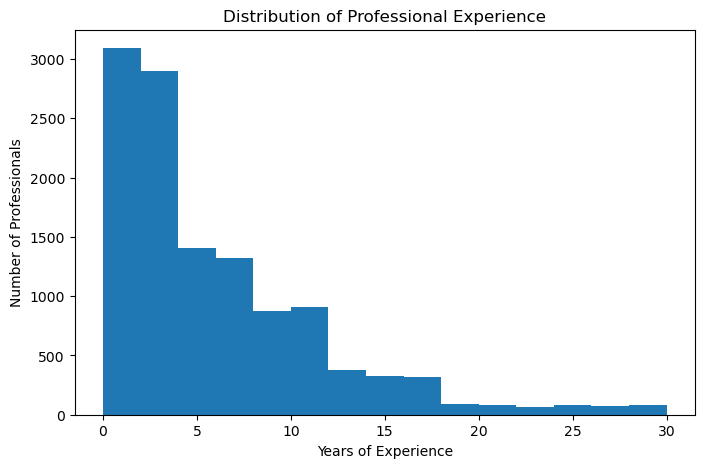

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    analysis_df["years_experience"],
    bins=15
)

plt.xlabel("Years of Experience")
plt.ylabel("Number of Professionals")
plt.title("Distribution of Professional Experience")

plt.show()

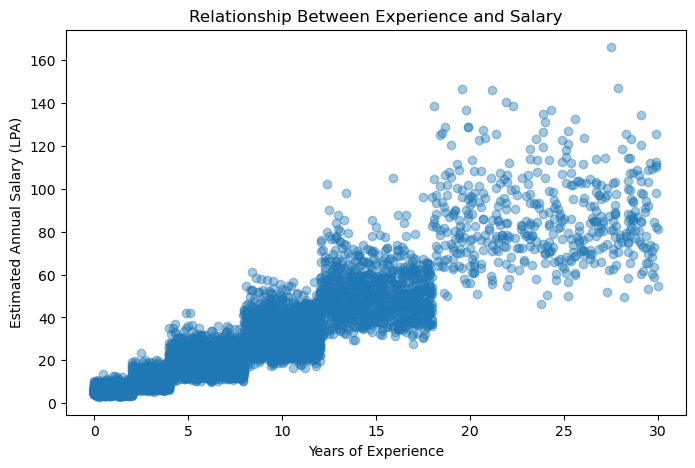

In [16]:
plt.figure(figsize=(8,5))

plt.scatter(
    analysis_df["years_experience"],
    analysis_df["estimated_annual_salary_lpa"],
    alpha=0.4
)

plt.xlabel("Years of Experience")
plt.ylabel("Estimated Annual Salary (LPA)")
plt.title("Relationship Between Experience and Salary")

plt.show()

In [17]:
analysis_df[
    [
        "years_experience",
        "estimated_annual_salary_lpa"
    ]
].corr()

,years_experience,estimated_annual_salary_lpa
years_experience,1.000000,0.920864
estimated_annual_salary_lpa,0.920864,1.000000


In [18]:
salary_seniority = (
    analysis_df
    .groupby("seniority_level")["estimated_annual_salary_lpa"]
    .median()
    .sort_values()
)

salary_seniority

seniority_level
Entry-level        5.9
Associate         10.2
Mid-Senior        18.4
Senior            31.1
Lead/Principal    48.8
Director+         83.3
Name: estimated_annual_salary_lpa, dtype: float64

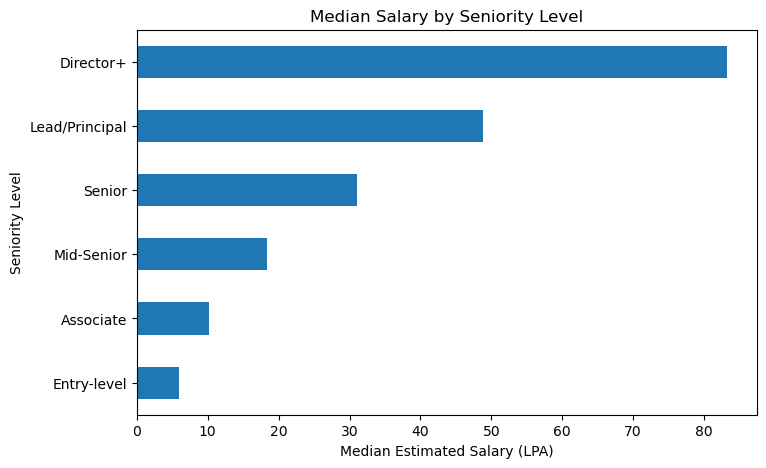

In [19]:
salary_seniority.plot(kind="barh", figsize=(8,5))

plt.xlabel("Median Estimated Salary (LPA)")
plt.ylabel("Seniority Level")
plt.title("Median Salary by Seniority Level")

plt.show()

In [20]:
domain_salary = (
    analysis_df
    .groupby("primary_skill_domain")
    .agg(
        median_salary=(
            "estimated_annual_salary_lpa",
            "median"
        ),
        professionals=("profile_id", "count")
    )
    .sort_values("median_salary", ascending=False)
)

domain_salary

,median_salary,professionals
primary_skill_domain,,
Cloud Computing,17.00,660
Cybersecurity,16.40,408
AI/ML,16.30,529
Data Science/Analytics,15.60,895
Core Engineering,13.70,727
UI/UX Design,13.60,491
Finance/Accounting,13.20,993
Product Management,13.15,686
Digital Marketing,13.05,1116


In [21]:
domain_salary_filtered = domain_salary[
    domain_salary["professionals"] >= 50
]

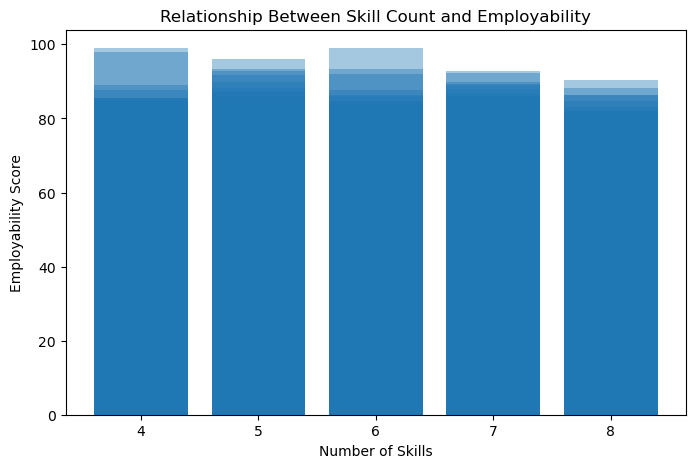

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    analysis_df["skill_count"],
    analysis_df["employability_score"],
    alpha=0.4
)

plt.xlabel("Number of Skills")
plt.ylabel("Employability Score")
plt.title("Relationship Between Skill Count and Employability")

plt.show()

In [25]:
analysis_df[
    ["skill_count", "employability_score"]
].corr()

,skill_count,employability_score
skill_count,1.000000,0.035465
employability_score,0.035465,1.000000


In [26]:
ai_summary = (
    analysis_df
    .groupby("uses_generative_ai_tools")
    .agg(
        professionals=("profile_id", "count"),
        median_salary=(
            "estimated_annual_salary_lpa",
            "median"
        ),
        median_employability=(
            "employability_score",
            "median"
        )
    )
)

ai_summary

,professionals,median_salary,median_employability
uses_generative_ai_tools,,,
No,1439,13.2,41.2
Yes,10561,13.6,50.2


In [27]:
data_analyst = analysis_df[
    analysis_df["current_job_title"]
    .str.contains(
        "data analyst",
        case=False,
        na=False
    )
].copy()

print(data_analyst.shape)

(895, 26)


In [28]:
data_analyst["top_skills"].head(20)

26     Python;R;Power BI;Statistics;Tableau;Data Visu...
28     Machine Learning;R;Tableau;Statistics;Power BI...
51     SQL;Data Visualization;Power BI;Python;Tableau...
59     Power BI;Statistics;SQL;Excel;Python;R;Machine...
74     R;Power BI;Data Visualization;Excel;SQL;Statis...
77     Statistics;Machine Learning;Python;Excel;R;Pow...
85                         Machine Learning;R;Python;SQL
96       SQL;Excel;Power BI;R;Data Visualization;Tableau
99               Tableau;Python;Data Visualization;Excel
111    R;Power BI;Data Visualization;Tableau;Statisti...
134               Machine Learning;R;Power BI;Statistics
138    R;Tableau;SQL;Excel;Data Visualization;Python;...
156            Tableau;Power BI;Excel;Data Visualization
182    Data Visualization;Power BI;R;SQL;Excel;Machin...
183    Machine Learning;R;Data Visualization;SQL;Pyth...
207    SQL;R;Excel;Python;Tableau;Statistics;Data Vis...
211    Machine Learning;Tableau;Python;SQL;Data Visua...
230    Machine Learning;Power B

In [29]:
skill_series = (
    analysis_df["top_skills"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

skill_counts = skill_series.value_counts()

skill_counts.head(20)

top_skills
Python              2156
SQL                 1794
Excel               1415
React               1253
REST APIs           1252
Node.js             1248
Spring Boot         1234
Git                 1231
Microservices       1223
System Design       1214
Java                1210
JavaScript          1190
User Research       1021
Email Marketing      952
SEM                  938
Salesforce           938
Lead Generation      936
Negotiation          928
Google Analytics     925
B2B Sales            923
Name: count, dtype: int64

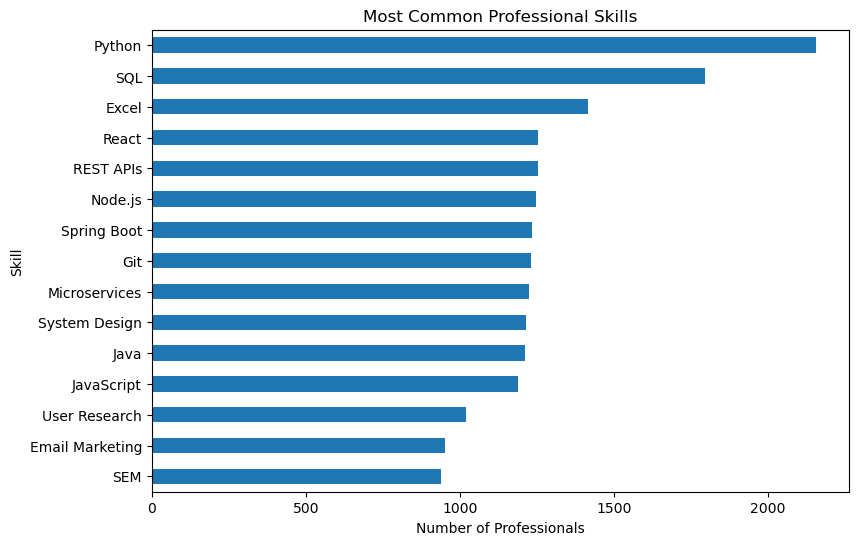

In [30]:
skill_counts.head(15).sort_values().plot(
    kind="barh",
    figsize=(9,6)
)

plt.xlabel("Number of Professionals")
plt.ylabel("Skill")
plt.title("Most Common Professional Skills")

plt.show()

In [31]:
da_skill_series = (
    data_analyst["top_skills"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

da_skill_counts = da_skill_series.value_counts()

da_skill_counts.head(15)

top_skills
SQL                   617
Power BI              603
Statistics            601
R                     594
Excel                 592
Data Visualization    584
Python                582
Tableau               581
Machine Learning      575
Name: count, dtype: int64

In [6]:
analysis_df.to_csv("cleaned_job_market_data.csv")